# 01 — Raw Data Exploration

## Holiday Farm Fire 2020 & Cedar Creek Fire 2022 — Eugene, OR

Pre-cleaning sanity check: load all three raw sources, summarize coverage **per fire event**,
and plot side-by-side overviews before running `02_data_cleaning.ipynb`.

**Sources:**
- **PurpleAir** — community sensors (22 in 2020 window, 57 in 2022)
- **NOAA ASOS KEUG** — Eugene Airport METAR
- **LRAPA** — regulatory PM2.5 (Eugene-area station mean)

This notebook does not produce analysis outputs; it only validates that raw files load and look reasonable.

In [1]:
import sys
sys.path.append('../src')

from data_loader import PurpleAirLoader, NOAALoader, LRAPALoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

SMOKE_THRESHOLD = 35  # µg/m³ — EPA 24h standard (reference line on plots)

EVENTS = {
    'Holiday Farm Fire 2020': {
        'color': '#d62728',
        'short': '2020',
        'start': pd.Timestamp('2020-08-01', tz='America/Los_Angeles'),
        'end':   pd.Timestamp('2020-10-15 23:59', tz='America/Los_Angeles'),
        'expected_hours': 76 * 24,  # Aug 1 – Oct 15
        'peak': ('2020-09-07', '2020-09-14'),
    },
    'Cedar Creek Fire 2022': {
        'color': '#1f77b4',
        'short': '2022',
        'start': pd.Timestamp('2022-08-01', tz='America/Los_Angeles'),
        'end':   pd.Timestamp('2022-09-30 23:59', tz='America/Los_Angeles'),
        'expected_hours': 61 * 24,  # Aug 1 – Sep 30
        'peak': ('2022-08-29', '2022-09-12'),
    },
}
EVENT_ORDER = list(EVENTS.keys())


def pm25_series(df):
    """Primary PM2.5 column; coalesce 2020 (pm2.5_cf_1) and 2022 (pm2.5_cf_1_a) naming."""
    if 'pm2.5_cf_1_a' in df.columns and 'pm2.5_cf_1' in df.columns:
        return df['pm2.5_cf_1_a'].fillna(df['pm2.5_cf_1'])
    if 'pm2.5_cf_1_a' in df.columns:
        return df['pm2.5_cf_1_a']
    if 'pm2.5_cf_1' in df.columns:
        return df['pm2.5_cf_1']
    raise KeyError('No PM2.5 CF=1 column found')


def tag_event(df, ts_col='timestamp'):
    """Assign event label from timestamp year (matches 02_data_cleaning)."""
    out = df.copy()
    year_map = {2020: 'Holiday Farm Fire 2020', 2022: 'Cedar Creek Fire 2022'}
    out['event'] = out[ts_col].dt.year.map(year_map).fillna('other')
    return out


def clip_event_window(df, event_name, ts_col='timestamp'):
    cfg = EVENTS[event_name]
    mask = (df[ts_col] >= cfg['start']) & (df[ts_col] <= cfg['end'])
    return df.loc[mask].copy()


def shade_peak(ax, event_name):
    p0, p1 = EVENTS[event_name]['peak']
    ax.axvspan(pd.Timestamp(p0), pd.Timestamp(p1), alpha=0.12,
               color=EVENTS[event_name]['color'])

## 0. Load all raw data

In [2]:
pa_raw = PurpleAirLoader('../data/raw/purpleair').load_all_sensors_in_directory()
pa_raw = tag_event(pa_raw)
pa_raw['pm25'] = pm25_series(pa_raw)

noaa_raw = NOAALoader('../data/raw/noaa').load_all_weather_data()
noaa_eug = noaa_raw[noaa_raw['station'] == 'EUG'].copy()
noaa_eug = tag_event(noaa_eug)

lrapa_raw = LRAPALoader('../data/raw/lrapa').load_all_lrapa_data()
lrapa_raw = tag_event(lrapa_raw)

print('=== Combined load summary ===')
for name, df, id_col in [
    ('PurpleAir', pa_raw, 'sensor_id'),
    ('NOAA KEUG', noaa_eug, None),
    ('LRAPA', lrapa_raw, None),
]:
    print(f'\n{name}: {len(df):,} rows')
    print(f'  Full range: {df["timestamp"].min()} → {df["timestamp"].max()}')
    for ev in EVENT_ORDER:
        sub = df[df['event'] == ev]
        extra = f', {sub[id_col].nunique()} sensors' if id_col and len(sub) else ''
        print(f'  {EVENTS[ev]["short"]}: {len(sub):,} rows{extra}')

Skipping bogus export(s) (filename starts with space; empty/failed download — you can delete these files):
  ../data/raw/purpleair/PurpleAir Download 5-5-2026/ 2022-08-01 2022-09-30 60-Minute Average.csv
  ../data/raw/purpleair/PurpleAir Download 5-17-2026/ 2020-08-01 2020-10-15 60-Minute Average.csv
Found 79 sensor data files
Detected data source: metar
Detected data source: metar
Loaded 1824 LRAPA records from LRAPAHourlyDataExport05172026-2.xlsx
Date range: 2020-08-01 02:00:00-07:00 → 2020-10-16 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
Loaded 1464 LRAPA records from LRAPAHourlyDataExport05052026-2.xlsx
Date range: 2022-08-01 02:00:00-07:00 → 2022-10-01 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
=== Combined load summary ===

PurpleAir: 87,167 rows
  Full range: 2020-07-31 17:00:00-07:00 → 2022-09-29 16:00:00-0

## 1. PurpleAir — per event

Side-by-side raw PM2.5 (median across sensors). Gray = individual sensors; bold line = hourly median.

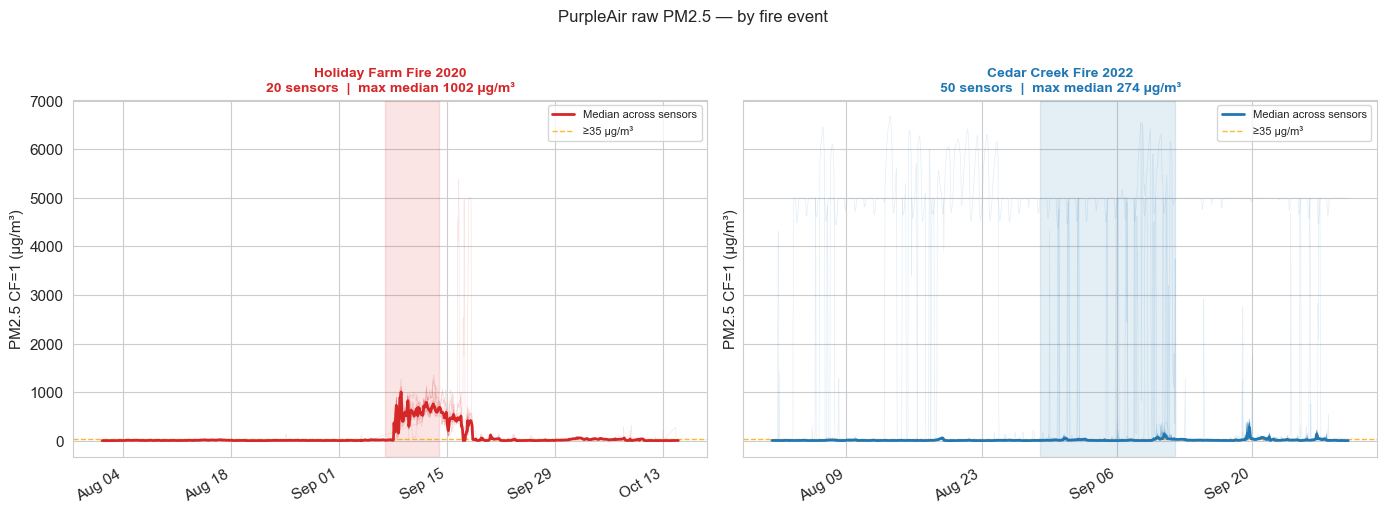

In [3]:
n_ev = len(EVENT_ORDER)
fig, axes = plt.subplots(1, n_ev, figsize=(7 * n_ev, 5), sharey=True, squeeze=False)

for col_idx, ev_name in enumerate(EVENT_ORDER):
    ax = axes[0, col_idx]
    color = EVENTS[ev_name]['color']
    sub = clip_event_window(pa_raw[pa_raw['event'] == ev_name], ev_name)

    for _, grp in sub.groupby('sensor_id'):
        ax.plot(grp['timestamp'], grp['pm25'],
                alpha=0.12, color=color, linewidth=0.5)

    median_ts = sub.groupby('timestamp')['pm25'].median()
    ax.plot(median_ts.index, median_ts.values,
            color=color, linewidth=2, label='Median across sensors', zorder=5)
    ax.axhline(SMOKE_THRESHOLD, color='orange', linestyle='--', linewidth=1,
               alpha=0.8, label=f'≥{SMOKE_THRESHOLD} µg/m³')
    shade_peak(ax, ev_name)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylabel('PM2.5 CF=1 (µg/m³)')
    ax.set_title(
        f'{ev_name}\n'
        f'{sub["sensor_id"].nunique()} sensors  |  '
        f'max median {median_ts.max():.0f} µg/m³',
        fontsize=10, color=color, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('PurpleAir raw PM2.5 — by fire event', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_pa_raw_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print('PurpleAir sensor coverage (within each event window):\n')
for ev_name in EVENT_ORDER:
    cfg = EVENTS[ev_name]
    sub = clip_event_window(pa_raw[pa_raw['event'] == ev_name], ev_name)
    expected = cfg['expected_hours']
    counts = sub.groupby('sensor_id')['timestamp'].count()
    pct = (counts / expected * 100).round(1)
    print(f'  {ev_name}')
    print(f'    Sensors: {sub["sensor_id"].nunique()}  |  Expected hrs/sensor: {expected}')
    print(f'    Median coverage: {pct.median():.1f}%  |  >90%: {(pct > 90).sum()} sensors')
    print(f'    Lowest coverage: {pct.min():.1f}%  |  Highest: {pct.max():.1f}%\n')

PurpleAir sensor coverage (within each event window):

  Holiday Farm Fire 2020
    Sensors: 20  |  Expected hrs/sensor: 1824
    Median coverage: 95.6%  |  >90%: 12 sensors
    Lowest coverage: 0.3%  |  Highest: 98.3%

  Cedar Creek Fire 2022
    Sensors: 50  |  Expected hrs/sensor: 1464
    Median coverage: 97.8%  |  >90%: 38 sensors
    Lowest coverage: 8.2%  |  Highest: 97.9%



## 2. NOAA KEUG — per event

Four-panel weather overview for each fire season (EUG station only).

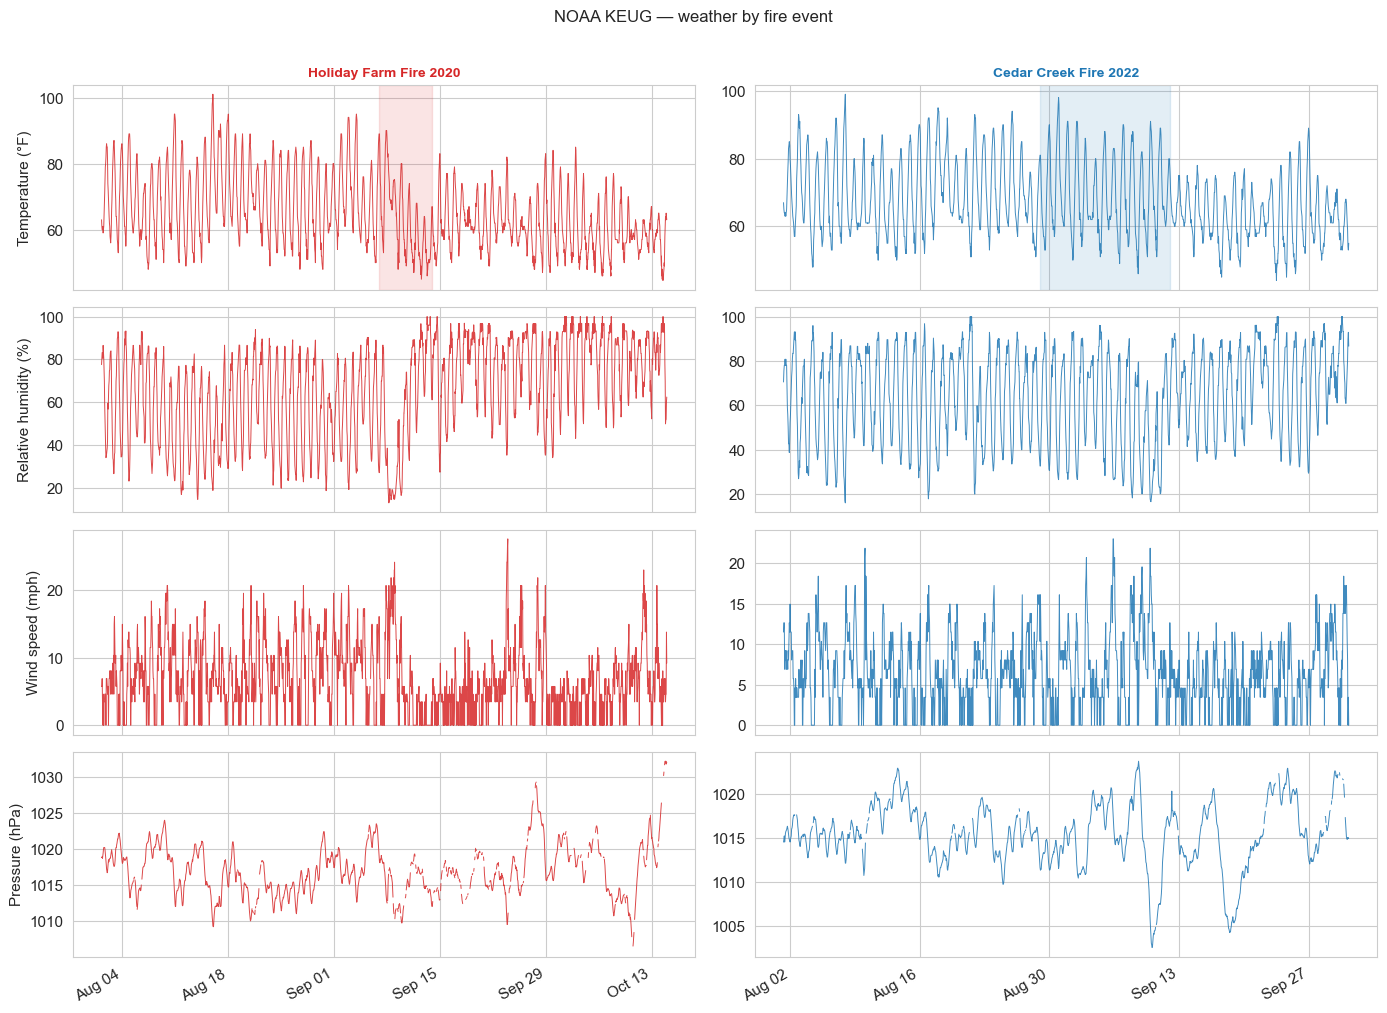

NOAA EUG date ranges:
  Holiday Farm Fire 2020: 2,276 obs  |  2020-08-01 00:54:00-07:00 → 2020-10-14 16:54:00-07:00
  Cedar Creek Fire 2022: 1,600 obs  |  2022-08-01 00:54:00-07:00 → 2022-09-30 23:54:00-07:00


In [5]:
weather_vars = [
    ('temperature_f', 'Temperature (°F)', 'tomato'),
    ('humidity', 'Relative humidity (%)', 'steelblue'),
    ('wind_speed_mph', 'Wind speed (mph)', 'seagreen'),
    ('pressure_hpa', 'Pressure (hPa)', 'mediumpurple'),
]

fig, axes = plt.subplots(len(weather_vars), n_ev,
                         figsize=(7 * n_ev, 10), sharex='col', squeeze=False)

for col_idx, ev_name in enumerate(EVENT_ORDER):
    color = EVENTS[ev_name]['color']
    sub = clip_event_window(noaa_eug[noaa_eug['event'] == ev_name], ev_name)

    for row_idx, (col, label, _) in enumerate(weather_vars):
        ax = axes[row_idx, col_idx]
        if col in sub.columns:
            ax.plot(sub['timestamp'], sub[col], color=color, linewidth=0.7, alpha=0.85)
        if row_idx == 0:
            ax.set_title(ev_name, fontsize=10, color=color, fontweight='bold')
            shade_peak(ax, ev_name)
        if col_idx == 0:
            ax.set_ylabel(label)
        if row_idx == len(weather_vars) - 1:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
            ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('NOAA KEUG — weather by fire event', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_noaa_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print('NOAA EUG date ranges:')
for ev_name in EVENT_ORDER:
    sub = clip_event_window(noaa_eug[noaa_eug['event'] == ev_name], ev_name)
    print(f'  {ev_name}: {len(sub):,} obs  |  {sub["timestamp"].min()} → {sub["timestamp"].max()}')

## 3. LRAPA regulatory PM2.5 — per event

Eugene-area station mean vs individual LRAPA monitors.

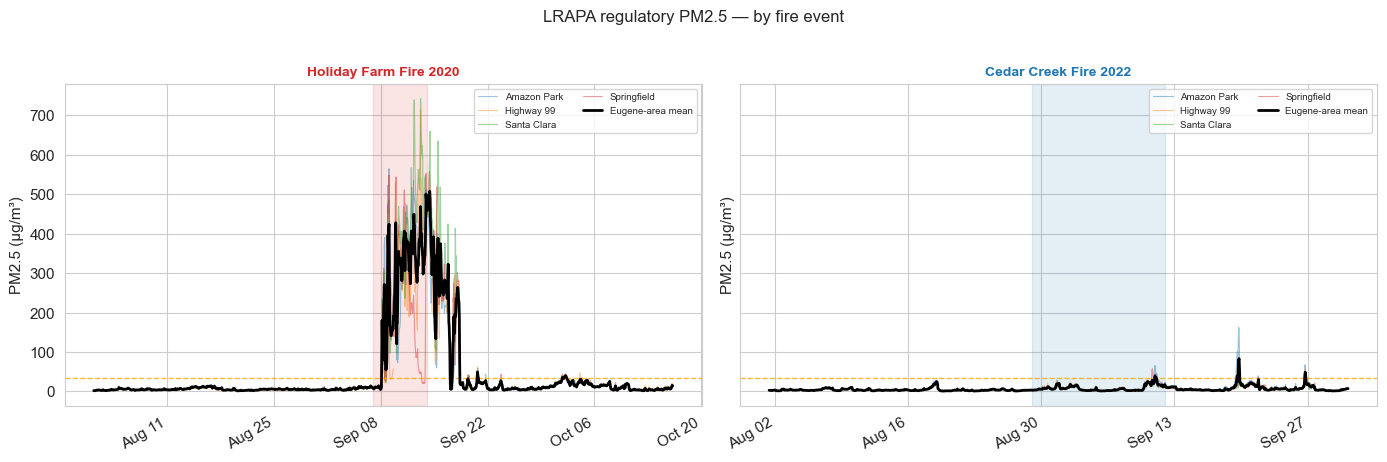

In [6]:
station_cols = ['pm2.5_amazon_park', 'pm2.5_highway_99',
                'pm2.5_santa_clara', 'pm2.5_springfield']
station_cols = [c for c in station_cols if c in lrapa_raw.columns]
station_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, n_ev, figsize=(7 * n_ev, 4.5), sharey=True, squeeze=False)

for col_idx, ev_name in enumerate(EVENT_ORDER):
    ax = axes[0, col_idx]
    color = EVENTS[ev_name]['color']
    sub = clip_event_window(lrapa_raw[lrapa_raw['event'] == ev_name], ev_name)

    for scol, sc in zip(station_cols, station_colors):
        ax.plot(sub['timestamp'], sub[scol], alpha=0.45, linewidth=0.8,
                color=sc, label=scol.replace('pm2.5_', '').replace('_', ' ').title())

    ax.plot(sub['timestamp'], sub['pm2.5_lrapa_regulatory'],
            color='black', linewidth=2, label='Eugene-area mean', zorder=5)
    ax.axhline(SMOKE_THRESHOLD, color='orange', linestyle='--', linewidth=1, alpha=0.8)
    shade_peak(ax, ev_name)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(ev_name, fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=7, ncol=2, loc='upper right')

plt.suptitle('LRAPA regulatory PM2.5 — by fire event', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_lrapa_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Quick comparison — smoke intensity by event

Regulatory (LRAPA) vs PurpleAir median on the same axes per event.

Holiday Farm Fire 2020:
  PurpleAir median max: 1002 µg/m³
  LRAPA mean max:       507 µg/m³
  Hours with PA median ≥ 35: 332

Cedar Creek Fire 2022:
  PurpleAir median max: 274 µg/m³
  LRAPA mean max:       83 µg/m³
  Hours with PA median ≥ 35: 102



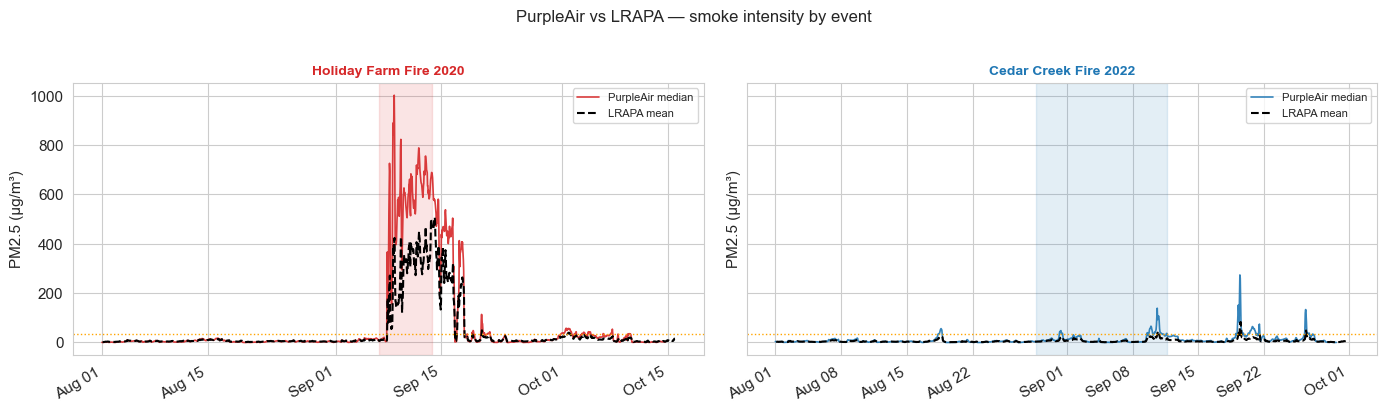

In [7]:
fig, axes = plt.subplots(1, n_ev, figsize=(7 * n_ev, 4), sharey=True, squeeze=False)

for col_idx, ev_name in enumerate(EVENT_ORDER):
    ax = axes[0, col_idx]
    color = EVENTS[ev_name]['color']

    pa_sub = clip_event_window(pa_raw[pa_raw['event'] == ev_name], ev_name)
    lr_sub = clip_event_window(lrapa_raw[lrapa_raw['event'] == ev_name], ev_name)
    pa_med = pa_sub.groupby('timestamp')['pm25'].median()

    ax.plot(pa_med.index, pa_med.values, color=color, linewidth=1.2,
            label='PurpleAir median', alpha=0.9)
    ax.plot(lr_sub['timestamp'], lr_sub['pm2.5_lrapa_regulatory'],
            color='black', linewidth=1.5, linestyle='--', label='LRAPA mean')
    ax.axhline(SMOKE_THRESHOLD, color='orange', linestyle=':', linewidth=1)
    shade_peak(ax, ev_name)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(ev_name, fontsize=10, color=color, fontweight='bold')
    ax.legend(fontsize=8)

    print(f'{ev_name}:')
    print(f'  PurpleAir median max: {pa_med.max():.0f} µg/m³')
    print(f'  LRAPA mean max:       {lr_sub["pm2.5_lrapa_regulatory"].max():.0f} µg/m³')
    hrs_smoke_pa = (pa_med >= SMOKE_THRESHOLD).sum()
    print(f'  Hours with PA median ≥ {SMOKE_THRESHOLD}: {hrs_smoke_pa}\n')

plt.suptitle('PurpleAir vs LRAPA — smoke intensity by event', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_pa_vs_lrapa_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Missing data — per event

In [8]:
pa_cols = ['pm25', 'pm2.5_cf_1_a', 'pm2.5_cf_1_b', 'humidity_a']
pa_cols = [c for c in pa_cols if c in pa_raw.columns or c == 'pm25']
noaa_cols = ['temperature_f', 'humidity', 'wind_speed_mph', 'pressure_hpa']

for ev_name in EVENT_ORDER:
    print('=' * 60)
    print(ev_name)
    print('=' * 60)

    pa_sub = clip_event_window(pa_raw[pa_raw['event'] == ev_name], ev_name)
    print('\nPurpleAir:')
    for col in pa_cols:
        if col in pa_sub.columns:
            print(f'  {col:22s}: {pa_sub[col].isna().mean() * 100:5.1f}% missing')

    noaa_sub = clip_event_window(noaa_eug[noaa_eug['event'] == ev_name], ev_name)
    print('\nNOAA KEUG:')
    for col in noaa_cols:
        if col in noaa_sub.columns:
            print(f'  {col:22s}: {noaa_sub[col].isna().mean() * 100:5.1f}% missing')

    lr_sub = clip_event_window(lrapa_raw[lrapa_raw['event'] == ev_name], ev_name)
    print('\nLRAPA:')
    print(f'  {"pm2.5_lrapa_regulatory":22s}: '
          f'{lr_sub["pm2.5_lrapa_regulatory"].isna().mean() * 100:5.1f}% missing')
    print()

Holiday Farm Fire 2020

PurpleAir:
  pm25                  :   0.0% missing
  pm2.5_cf_1_a          :   0.0% missing
  pm2.5_cf_1_b          :   0.0% missing
  humidity_a            : 100.0% missing

NOAA KEUG:
  temperature_f         :   0.0% missing
  humidity              :   0.0% missing
  wind_speed_mph        :   0.1% missing
  pressure_hpa          :  21.3% missing

LRAPA:
  pm2.5_lrapa_regulatory:   0.0% missing

Cedar Creek Fire 2022

PurpleAir:
  pm25                  :   0.0% missing
  pm2.5_cf_1_a          :   0.0% missing
  pm2.5_cf_1_b          :   0.0% missing
  humidity_a            :   2.9% missing

NOAA KEUG:
  temperature_f         :   0.0% missing
  humidity              :   0.0% missing
  wind_speed_mph        :   0.0% missing
  pressure_hpa          :   8.6% missing

LRAPA:
  pm2.5_lrapa_regulatory:   0.0% missing



## Next step

Run **`02_data_cleaning.ipynb`** to apply LRAPA correction, QC, alignment, and produce `data/processed/analysis_data.csv` with an `event` column for notebooks 03–07.